# Adaptive Fixation–Saccade Classification Using K-Ratio Minimization
## Waldo Task — Step-by-Step Example

**Paper:** Orioma, Krivan, Mathema, Lencastre, Lind, Szorkovszky, Bhandari (2026)  
*"Identification of fixations and saccades in eye-tracking data using adaptive threshold-based methods"*  
arXiv: 2512.23926

---

**Dataset:** Waldo (visual search) — 15 participants, ~405k samples/participant, 1000 Hz  
**Algorithms:** I-VT · I-AVT · I-DT  
**Method:** K-ratio minimization for adaptive threshold selection

---
**Data setup:** Place your Waldo `.txt` EyeLink files in a folder and set `DATA_DIR` below.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import warnings
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

warnings.filterwarnings("ignore")

# ========================
# Import kratio package
# ========================
import sys
sys.path.insert(0, "..")   # adjust if running from repo root

from kratio import (
    load_waldo_directory, preprocess_waldo,
    compute_velocity, compute_effective_velocity, binocular_coordination,
    compute_k_ratio,
    apply_ivt,  optimize_ivt_threshold,
    apply_iavt, optimize_iavt_threshold,
    apply_idt,  optimize_idt_threshold, grid_search_idt,
    add_gaussian_noise, run_noise_sweep,
    plot_markov_diagnostics,
)

os.makedirs("../outputs", exist_ok=True)
print("Imports OK")

Imports OK


## 1 · Configuration

In [4]:
# ========================
# Configuration
# ========================

#DATA_DIR        = "../extracted_waldo"   # folder with .txt EyeLink files 
DATA_DIR        = "../extracted_randomPixel"   # folder with .txt EyeLink files 
MAX_FILES       = 5                  # set to 2-3 for a quick demo run
REMOVE_NANBEFORE = 500                # NaN margin parameter (original algorithm)
SAMPLE_SIZE     = 200000              # samples used for noise sweep
NOISE_LEVELS    = [0, 1, 2, 5, 10, 30, 40, 50]

# I-DT parameters
IDT_WINDOW_SIZE           = 10    # sliding window for dispersion series
IDT_FIXED_DURATION_SAMPLES = 50   # min window run-length → fixation

print(f"Data directory : {DATA_DIR}")
print(f"Max files      : {MAX_FILES}")

Data directory : ../extracted_randomPixel
Max files      : 5


## 2 · Data Loading and Preprocessing

Load EyeLink `.txt` files, remove NaN runs (500-sample margin, both eyes),
and concatenate across participants.

In [5]:
# ========================
# Data Loading and Preprocessing
# ========================

all_data = load_waldo_directory(DATA_DIR, max_files=MAX_FILES)

data = preprocess_waldo(all_data, remove_nanbefore=REMOVE_NANBEFORE)

# Unpack for convenience
filtered_time           = data['filtered_time']
filtered_x_left         = data['filtered_x_left']
filtered_y_left         = data['filtered_y_left']
filtered_x_right        = data['filtered_x_right']
filtered_y_right        = data['filtered_y_right']
filtered_category_left  = data['filtered_category_left']
filtered_category_right = data['filtered_category_right']
filtered_saccade        = data['filtered_saccade']
filtered_fixation       = data['filtered_fixation']

print(f"\nFirst 5 rows of first file:")
print(all_data[0].head())

Total files loaded: 5
  File 1: Shape = (180018, 10)
  File 2: Shape = (180020, 10)
  File 3: Shape = (180020, 10)
  File 4: Shape = (180011, 10)
  File 5: Shape = (180003, 10)
Total samples after NaN filtering: 22,165
Unique fixation labels : [0 1]
Unique saccade labels  : [0 1]

First 5 rows of first file:
         col_0  col_1  col_2  col_3  col_4  col_5  col_6  col_7  col_8  col_9
0  688771539.0  687.4  633.6  912.0  644.6  631.6  993.0    0.0    0.0    0.0
1  688771540.0  687.0  634.6  912.0  644.4  631.6  993.0    0.0    0.0    0.0
2  688771541.0  686.7  635.8  912.0  644.4  631.8  993.0    0.0    0.0    0.0
3  688771542.0  686.8  636.6  912.0  644.3  632.2  993.0    0.0    0.0    0.0
4  688771543.0  687.1  636.4  912.0  644.9  632.6  992.0    0.0    0.0    0.0


## 3 · Binocular Coordination

Binocular X correlation : 0.9972
Binocular Y correlation : 0.9947
Fixation agreement      : 99.24%
Saccade agreement       : 92.39%


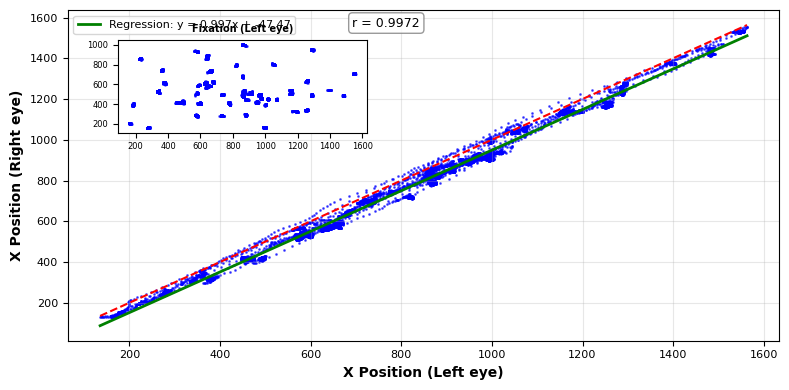

In [6]:
# ========================
# Binocular Coordination
# ========================

bino = binocular_coordination(data)

# Visualization: left vs right X positions
fig1, ax1 = plt.subplots(figsize=(8, 4))
ax1.scatter(filtered_x_left, filtered_x_right, s=1, alpha=0.6, c='blue')
ax1.plot([filtered_x_left.min(), filtered_x_left.max()],
         [filtered_x_left.min(), filtered_x_left.max()], 'r--')
slope_x, intercept_x = np.polyfit(filtered_x_left, filtered_x_right, 1)
x_range = np.linspace(filtered_x_left.min(), filtered_x_left.max(), 100)
ax1.plot(x_range, slope_x * x_range + intercept_x, 'g-', linewidth=2,
         label=f'Regression: y = {slope_x:.3f}x + {intercept_x:.2f}')
ax1.set_xlabel("X Position (Left eye)", fontsize=10, fontweight='bold')
ax1.set_ylabel("X Position (Right eye)", fontsize=10, fontweight='bold')
ax1.annotate(f"r = {bino['x_corr']:.4f}", xy=(0.4, 0.95),
             xycoords='axes fraction', fontsize=9,
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='both', labelsize=8)

# Inset: left eye fixation cluster
common_fix_idx = np.where(
    (filtered_category_left == 1) & (filtered_category_right == 1))[0]
axins = inset_axes(ax1, width="100%", height="100%",
                   bbox_to_anchor=(0.08, 0.65, 0.35, 0.28),
                   bbox_transform=ax1.transAxes)
axins.scatter(filtered_x_left[common_fix_idx],
              filtered_y_left[common_fix_idx], s=1, alpha=0.5, c='blue')
axins.set_title("Fixation (Left eye)", fontsize=7, fontweight='bold')
axins.tick_params(labelsize=6)

plt.tight_layout()
plt.savefig("../outputs/binocular_coordination_Waldo.pdf", dpi=300, bbox_inches='tight')
plt.show()

## 4 · Velocity and Effective Velocity Computation

I-VT  velocity array length : 22,164
I-AVT eff-velocity array len : 21,883


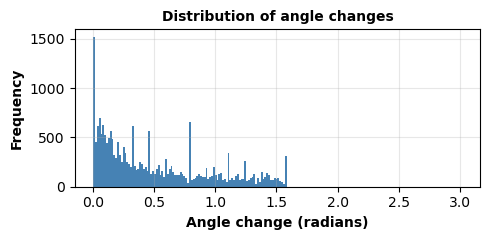

In [7]:
# ========================
# Velocity and Angle Calculations (Left Eye Focused)
# ========================

point_velo = compute_velocity(filtered_x_left, filtered_y_left, filtered_time)

point_velo_eff, x_val_corr, y_val_corr, valid_theta_indices = compute_effective_velocity(
    filtered_x_left, filtered_y_left, filtered_time)

print(f"I-VT  velocity array length : {len(point_velo):,}")
print(f"I-AVT eff-velocity array len : {len(point_velo_eff):,}")

# Angle histogram
theta_np = np.arccos(np.clip(
    point_velo_eff / (point_velo[:-1][valid_theta_indices] + 1e-12),
    -1.0, 1.0))

plt.figure(figsize=(5, 2.5))
plt.hist(theta_np[np.isfinite(theta_np)], bins=200, color='steelblue', edgecolor='none')
plt.xlabel("Angle change (radians)", fontsize=10, fontweight='bold')
plt.ylabel("Frequency", fontsize=10, fontweight='bold')
plt.title("Distribution of angle changes", fontsize=10, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5 · K-Ratio Optimization

Sweep thresholds for each algorithm and find the minimum K-ratio (Fig. 2 of paper).

In [ ]:
# K-ratio Optimization — I-VT
thresholds_ivt, k_ratios_ivt, ivt_optimal_threshold, ivt_min_idx =     optimize_ivt_threshold(point_velo, num_thresholds=200, pct_low=5, pct_high=96)

# K-ratio Optimization — I-AVT
thresholds_avt, k_ratios_avt, iavt_optimal_threshold, iavt_min_idx =     optimize_iavt_threshold(point_velo_eff, num_thresholds=200, pct_low=0, pct_high=96)

# K-ratio Optimization — I-DT (grid search + sweep)
best_params, best_k_idt = grid_search_idt(
    filtered_x_left, filtered_y_left, filtered_time,
    xy_thresholds=np.linspace(5, 90, 10),
    dur_thresholds=np.linspace(0.05, 0.5, 5)
)

sampling_rate = 1000
fixed_duration_samples = int(best_params['dur_threshold'] * sampling_rate)

thresholds_idt, k_ratios_idt, idt_optimal_disp, idt_min_idx =     optimize_idt_threshold(
        filtered_x_left, filtered_y_left,
        window_size=IDT_WINDOW_SIZE,
        fixed_duration_samples=IDT_FIXED_DURATION_SAMPLES,
        num_thresholds=50
    )

print(f"\nI-AVT: optimal threshold = {iavt_optimal_threshold:.2f} px/s,  K-ratio = {k_ratios_avt[iavt_min_idx]:.4f}")
print(f"I-VT : optimal threshold = {ivt_optimal_threshold:.2f}  px/s,  K-ratio = {k_ratios_ivt[ivt_min_idx]:.4f}")
print(f"I-DT : optimal threshold = {idt_optimal_disp:.2f}  px,    K-ratio = {k_ratios_idt[idt_min_idx]:.4f}")

Starting I-DT grid search...
Optimal I-DT params: {'x_y_threshold': np.float64(90.0), 'dur_threshold': np.float64(0.05)}, K-ratio = 0.2415

I-AVT: optimal threshold = 6.30 px/s,  K-ratio = 0.0962
I-VT : optimal threshold = 5.79  px/s,  K-ratio = 0.0946
I-DT : optimal threshold = 7.78  px,    K-ratio = 0.0103


### 5.1 · K-Ratio Curves (Fig. 2 style)

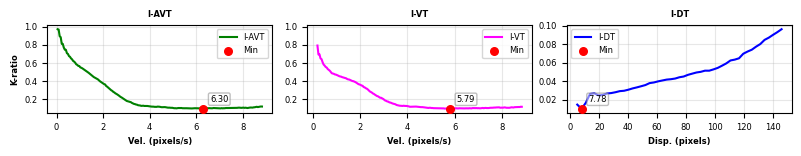

In [9]:
# K-ratio Curves Plot (independent y-scale for I-DT)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8, 1.5))
ax2.sharey(ax1)

# I-AVT
ax1.plot(thresholds_avt, k_ratios_avt, c="green", linewidth=1.5, label="I-AVT")
ax1.scatter(thresholds_avt[iavt_min_idx], k_ratios_avt[iavt_min_idx],
            c="red", s=30, label="Min", zorder=5)
ax1.annotate(f"{iavt_optimal_threshold:.2f}",
             xy=(thresholds_avt[iavt_min_idx], k_ratios_avt[iavt_min_idx]),
             xytext=(5, 5), textcoords='offset points', fontsize=6,
             bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="gray", alpha=0.5))
ax1.set_xlabel("Vel. (pixels/s)", fontsize=6, fontweight='bold')
ax1.set_ylabel("K-ratio", fontsize=6, fontweight='bold')
ax1.set_title("I-AVT", fontsize=6, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=6)
ax1.tick_params(axis='both', labelsize=6)

# I-VT
ax2.plot(thresholds_ivt, k_ratios_ivt, c="magenta", linewidth=1.5, label="I-VT")
ax2.scatter(thresholds_ivt[ivt_min_idx], k_ratios_ivt[ivt_min_idx],
            c="red", s=30, label="Min", zorder=5)
ax2.annotate(f"{ivt_optimal_threshold:.2f}",
             xy=(thresholds_ivt[ivt_min_idx], k_ratios_ivt[ivt_min_idx]),
             xytext=(5, 5), textcoords='offset points', fontsize=6,
             bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="gray", alpha=0.5))
ax2.set_xlabel("Vel. (pixels/s)", fontsize=6, fontweight='bold')
ax2.set_title("I-VT", fontsize=6, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=6)
ax2.tick_params(axis='both', labelsize=6)

# I-DT (independent y-scale)
ax3.plot(thresholds_idt, k_ratios_idt, c="blue", linewidth=1.5, label="I-DT")
ax3.scatter(thresholds_idt[idt_min_idx], k_ratios_idt[idt_min_idx],
            c="red", s=30, label="Min", zorder=5)
ax3.annotate(f"{idt_optimal_disp:.2f}",
             xy=(thresholds_idt[idt_min_idx], k_ratios_idt[idt_min_idx]),
             xytext=(5, 5), textcoords='offset points', fontsize=6,
             bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="gray", alpha=0.5))
ax3.set_xlabel("Disp. (pixels)", fontsize=6, fontweight='bold')
ax3.set_title("I-DT", fontsize=6, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.legend(fontsize=6)
ax3.tick_params(axis='both', labelsize=6)

plt.tight_layout(pad=0.5)
plt.savefig("../outputs/k_ratio_Waldo.pdf", dpi=300, format='pdf', bbox_inches='tight')
plt.show()

## 6 · Apply Algorithms at Optimal Thresholds

In [10]:
# Algorithm Application
# I-VT
x_ivt = filtered_x_left[:len(point_velo)]
y_ivt = filtered_y_left[:len(point_velo)]
ivt_results = apply_ivt(point_velo, x_ivt, y_ivt, ivt_optimal_threshold)

# I-AVT
x_iavt = x_val_corr[:len(point_velo_eff)]
y_iavt = y_val_corr[:len(point_velo_eff)]
iavt_results = apply_iavt(point_velo_eff, x_iavt, y_iavt, iavt_optimal_threshold)

# I-DT
idt_results = apply_idt(
    filtered_x_left, filtered_y_left, filtered_time,
    best_params['x_y_threshold'], best_params['x_y_threshold'],
    best_params['dur_threshold']
)

for name, res in [("I-VT", ivt_results), ("I-AVT", iavt_results), ("I-DT", idt_results)]:
    n_fix = res['classifier'].count("fixation")
    n_sac = res['classifier'].count("saccade")
    total = n_fix + n_sac
    print(f"{name:6s}: fixations={n_fix:7,} ({100*n_fix/total:.1f}%)  "
          f"saccades={n_sac:6,} ({100*n_sac/total:.1f}%)")

I-VT  : fixations= 20,835 (94.0%)  saccades= 1,329 (6.0%)
I-AVT : fixations= 20,661 (94.4%)  saccades= 1,222 (5.6%)
I-DT  : fixations= 21,578 (97.4%)  saccades=   587 (2.6%)


## 7 · Scanpath Visualization (Fig. 1 style)

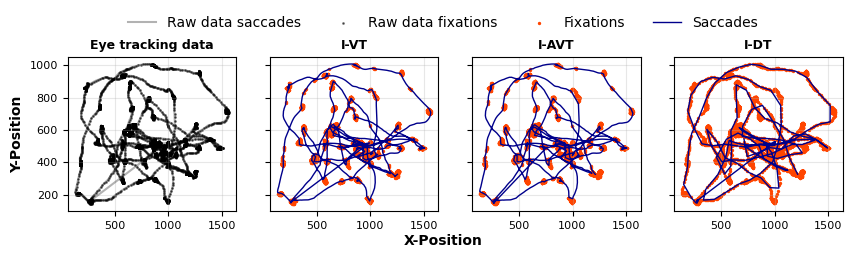

In [12]:
# Scanpath Visualization (Fig. 1 of paper)
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(10, 2), sharex=True, sharey=True)

axis_fs = 10

ax1.plot(filtered_x_left, filtered_y_left, 'k-', alpha=0.3)
ax1.scatter(filtered_x_left, filtered_y_left, s=1, c='black', alpha=0.5, marker='o')
ax1.set_ylabel("Y-Position", fontsize=axis_fs, fontweight='bold')
ax1.set_title("Eye tracking data", fontsize=9, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='both', labelsize=8)

ax2.scatter(ivt_results['x_fix'],  ivt_results['y_fix'],  s=2, c="#FF4500", alpha=1, marker='o')
ax2.plot(   ivt_results['x_sac'],  ivt_results['y_sac'],  '-', color="#00008B", linewidth=1, alpha=1)
ax2.set_title("I-VT", fontsize=9, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='both', labelsize=8)

ax3.plot(   iavt_results['x_sac'], iavt_results['y_sac'], '-', color="#00008B", linewidth=1, alpha=1)
ax3.scatter(iavt_results['x_fix'], iavt_results['y_fix'], s=2, c="#FF4500", alpha=1, marker='o')
ax3.set_title("I-AVT", fontsize=9, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.tick_params(axis='both', labelsize=8)

ax4.scatter(idt_results['x_fix'],  idt_results['y_fix'],  s=2, c="#FF4500", alpha=1, marker='o')
ax4.plot(   idt_results['x_sac'],  idt_results['y_sac'],  '-', color="#00008B", linewidth=1, alpha=1)
ax4.set_title("I-DT", fontsize=9, fontweight='bold')
ax4.grid(True, alpha=0.3)
ax4.tick_params(axis='both', labelsize=8)

fig.text(0.5, -0.06, 'X-Position', ha='center', fontsize=axis_fs, fontweight='bold')
fig.legend(['Raw data saccades', 'Raw data fixations', 'Fixations', 'Saccades'],
           loc='upper center', ncol=4, fontsize=10,
           bbox_to_anchor=(0.5, 1.15), frameon=False)

plt.savefig("../outputs/scanpath_comparison_Waldo.png",
            dpi=600, bbox_inches='tight', pad_inches=0.05)
plt.show()

## 8 · Performance Metrics vs EyeLink Reference (Fig. 3 style)

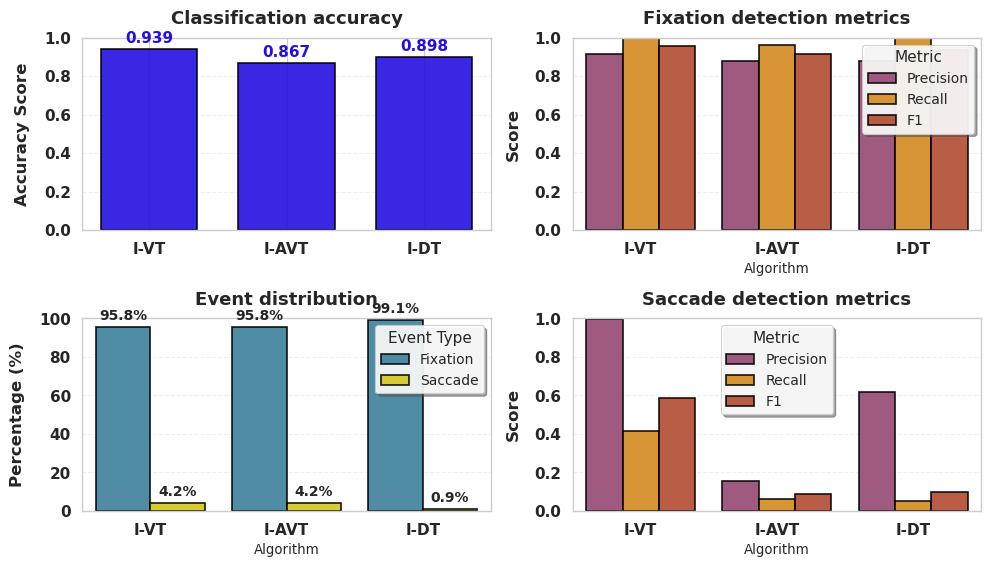


ALGORITHM PERFORMANCE SUMMARY
Algorithm  Accuracy  Precision (Fix)  Recall (Fix)  F1 (Fix)  Precision (Sac)  Recall (Sac)  F1 (Sac)  Fixation %  Saccade %
     I-VT    0.9393           0.9156        1.0000    0.9559           0.9990        0.4161    0.5875     95.7653     4.2347
    I-AVT    0.8674           0.8784        0.9603    0.9176           0.1539        0.0633    0.0897     95.8327     4.1673
     I-DT    0.8982           0.8812        0.9963    0.9352           0.6158        0.0522    0.0963     99.1378     0.8622


In [ ]:
# Performance metrics dashboard
# ========================

def bold_ticks(ax, size=11, weight="bold"):
    ax.tick_params(axis='both', which='both', labelsize=size, width=1.5)
    for lbl in ax.get_xticklabels(): lbl.set_fontweight(weight)
    for lbl in ax.get_yticklabels(): lbl.set_fontweight(weight)

def set_xylabels(ax, xlabel=None, ylabel=None, size=12, weight="bold"):
    if xlabel: ax.set_xlabel(xlabel, fontsize=size, fontweight=weight, labelpad=10)
    if ylabel: ax.set_ylabel(ylabel, fontsize=size, fontweight=weight, labelpad=10)

def set_title(ax, title, size=13, weight="bold"):
    ax.set_title(title, fontsize=size, fontweight=weight, pad=10)

sns.set_theme(style="whitegrid", context="paper")

algorithms = {'I-VT': ivt_results, 'I-AVT': iavt_results, 'I-DT': idt_results}
summary_rows = []

for algo_name, results in algorithms.items():
    predictions = np.array([1 if c == 'fixation' else 2 for c in results['classifier']])
    L = min(len(filtered_category_left), len(predictions))
    y_true = filtered_category_left[:L]
    y_pred = predictions[:L]

    cm = confusion_matrix(y_true, y_pred, labels=[1, 2])
    report = classification_report(
        y_true, y_pred, target_names=['Fixation', 'Saccade'],
        labels=[1, 2], output_dict=True, zero_division=0)

    accuracy = (cm[0, 0] + cm[1, 1]) / cm.sum() if cm.sum() > 0 else 0.0
    fix_pct  = 100.0 * np.sum(y_pred == 1) / max(len(y_pred), 1)
    sac_pct  = 100.0 * np.sum(y_pred == 2) / max(len(y_pred), 1)
    summary_rows.append({
        'Algorithm': algo_name, 'Accuracy': accuracy,
        'Precision (Fix)': report['Fixation']['precision'],
        'Recall (Fix)':    report['Fixation']['recall'],
        'F1 (Fix)':        report['Fixation']['f1-score'],
        'Precision (Sac)': report['Saccade']['precision'],
        'Recall (Sac)':    report['Saccade']['recall'],
        'F1 (Sac)':        report['Saccade']['f1-score'],
        'Fixation %':  fix_pct, 'Saccade %': sac_pct
    })

summary_df = pd.DataFrame(summary_rows)
summary_df['Algorithm'] = pd.Categorical(
    summary_df['Algorithm'], categories=['I-VT', 'I-AVT', 'I-DT'], ordered=True)
summary_df = summary_df.sort_values('Algorithm')

professional_palette = {
    'accuracy':  "#240FE2",
    'precision': '#A23B72',
    'recall':    '#F18F01',
    'f1':        '#C73E1D',
    'fixation':  '#2E86AB',
    'saccade':   "#F1E101"
}
PAL_FIX = {"Precision": professional_palette['precision'],
            "Recall":    professional_palette['recall'],
            "F1":        professional_palette['f1']}
PAL_EVT = {"Fixation":  professional_palette['fixation'],
            "Saccade":   professional_palette['saccade']}

fig_metrics = plt.figure(figsize=(10, 6))

# Accuracy
ax1 = plt.subplot(2, 2, 1)
x = np.arange(len(summary_df))
vals = summary_df['Accuracy'].astype(float).to_numpy()
bars = ax1.bar(x, vals, color=professional_palette['accuracy'],
               edgecolor='black', linewidth=1.2, alpha=0.9, width=0.7)
ax1.set_xticks(x); ax1.set_xticklabels(summary_df['Algorithm'], fontweight='bold')
set_title(ax1, 'Classification accuracy')
set_xylabels(ax1, None, "Accuracy Score")
ax1.set_ylim(0, 1); ax1.grid(True, axis='y', alpha=0.3, linestyle='--')
bold_ticks(ax1)
for bar, v in zip(bars, vals):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
             f"{v:.3f}", ha='center', va='bottom', fontsize=11, fontweight="bold",
             color=professional_palette['accuracy'])

# Fixation detection metrics
ax2 = plt.subplot(2, 2, 2)
fix_df = summary_df.melt(id_vars=['Algorithm'],
    value_vars=['Precision (Fix)', 'Recall (Fix)', 'F1 (Fix)'],
    var_name='Metric', value_name='Value')
fix_df['Metric'] = fix_df['Metric'].str.replace(' (Fix)', '', regex=False)
sns.barplot(x='Algorithm', y='Value', hue='Metric', data=fix_df,
            palette=PAL_FIX, edgecolor='black', linewidth=1.2,
            errorbar=None, ax=ax2, alpha=0.9)
set_title(ax2, 'Fixation detection metrics')
set_xylabels(ax2, None, "Score")
ax2.set_ylim(0, 1); ax2.grid(True, axis='y', alpha=0.3, linestyle='--')
bold_ticks(ax2)
ax2.legend(title='Metric', frameon=True, fancybox=True,
           shadow=True, framealpha=0.9, fontsize=10, title_fontsize=11)

# Event distribution
ax4 = plt.subplot(2, 2, 3)
evt_df = summary_df.melt(id_vars=['Algorithm'],
    value_vars=['Fixation %', 'Saccade %'],
    var_name='Event Type', value_name='Percentage')
evt_df['Event Type'] = evt_df['Event Type'].str.replace(' %', '', regex=False)
sns.barplot(x='Algorithm', y='Percentage', hue='Event Type', data=evt_df,
            palette=PAL_EVT, edgecolor='black', linewidth=1.2,
            errorbar=None, ax=ax4, alpha=0.9)
set_title(ax4, 'Event distribution')
set_xylabels(ax4, None, "Percentage (%)")
ax4.set_ylim(0, 100); ax4.grid(True, axis='y', alpha=0.3, linestyle='--')
bold_ticks(ax4)
ax4.legend(title='Event Type', frameon=True, fancybox=True,
           shadow=True, framealpha=0.9, fontsize=10, title_fontsize=11)
for container in ax4.containers:
    ax4.bar_label(container, fmt="%.1f%%", fontsize=10, fontweight="bold", padding=3)

# Saccade detection metrics
ax3 = plt.subplot(2, 2, 4)
sac_df = summary_df.melt(id_vars=['Algorithm'],
    value_vars=['Precision (Sac)', 'Recall (Sac)', 'F1 (Sac)'],
    var_name='Metric', value_name='Value')
sac_df['Metric'] = sac_df['Metric'].str.replace(' (Sac)', '', regex=False)
sns.barplot(x='Algorithm', y='Value', hue='Metric', data=sac_df,
            palette=PAL_FIX, edgecolor='black', linewidth=1.2,
            errorbar=None, ax=ax3, alpha=0.9)
set_title(ax3, 'Saccade detection metrics')
set_xylabels(ax3, None, "Score")
ax3.set_ylim(0, 1); ax3.grid(True, axis='y', alpha=0.3, linestyle='--')
bold_ticks(ax3)
ax3.legend(title='Metric', frameon=True, fancybox=True,
           shadow=True, framealpha=0.9, fontsize=10, title_fontsize=11)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("../outputs/performance_metrics_Waldo.pdf",
            dpi=300, format='pdf', bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print("ALGORITHM PERFORMANCE SUMMARY")
print("="*60)
print(summary_df.round(4).to_string(index=False))
print("="*60)

## 9 · Markov Adequacy Diagnostics (Appendix A style)

Verify the stationarity assumption underlying the K-ratio framework:
- **(a)** Blockwise nS, p(F→S), p(S→F) across 12 temporal blocks
- **(b)** Blockwise K-ratio stability
- **(c)** ||T_emp(k) − T^k|| as a function of lag k

Saved: ../outputs/markov_diagnostics_Waldo.pdf


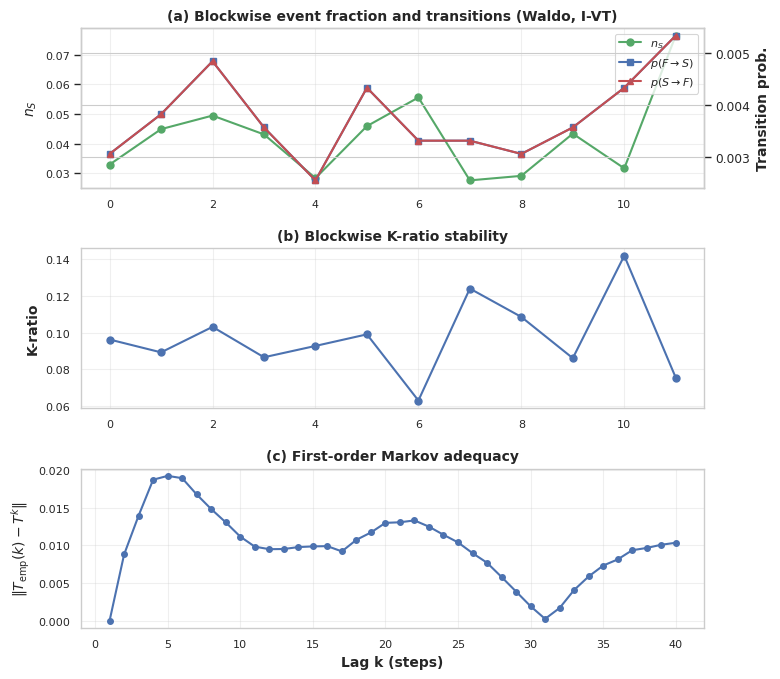


Blockwise K-ratio: mean = 0.0971, std = 0.0200, range = [0.0632, 0.1416]
T^k deviation at k=2 : 8.80e-03
T^k deviation at k=5 : 1.92e-02


In [14]:
# ========================
# Markov Adequacy Diagnostics (Fig. A1 of paper)
# ========================

# Use I-VT classifier at optimal threshold for the diagnostics
bw_results, lags, devs = plot_markov_diagnostics(
    ivt_results['classifier'],
    n_blocks=12,
    max_lag=40,
    save_path="../outputs/markov_diagnostics_Waldo.pdf",
    title_suffix="(Waldo, I-VT)"
)

## 10 · Gaussian Noise Robustness Analysis (Fig. 4 style)

Test how adaptive K-ratio thresholds respond to increasing Gaussian spatial noise
σ = 0–50 pixels, for all three algorithms.

In [15]:
# ========================
# Gaussian Noise Robustness Sweep
# ========================

N = min(SAMPLE_SIZE, len(filtered_x_left))
x_sample = filtered_x_left[:N]
y_sample  = filtered_y_left[:N]
time_sample = filtered_time[:N]

print(f"Running noise sweep on {N:,} samples...")
sweep = run_noise_sweep(
    x_sample, y_sample, time_sample,
    noise_levels=NOISE_LEVELS,
    idt_window_size=IDT_WINDOW_SIZE,
    idt_fixed_duration_samples=IDT_FIXED_DURATION_SAMPLES,
    verbose=True
)

Running noise sweep on 47,088 samples...
  Noise level: 0
  Noise level: 1
  Noise level: 2
  Noise level: 5
  Noise level: 10
  Noise level: 30
  Noise level: 40
  Noise level: 50


### 10.1 · Adaptive Thresholds vs Noise Level (Fig. 4 top row)

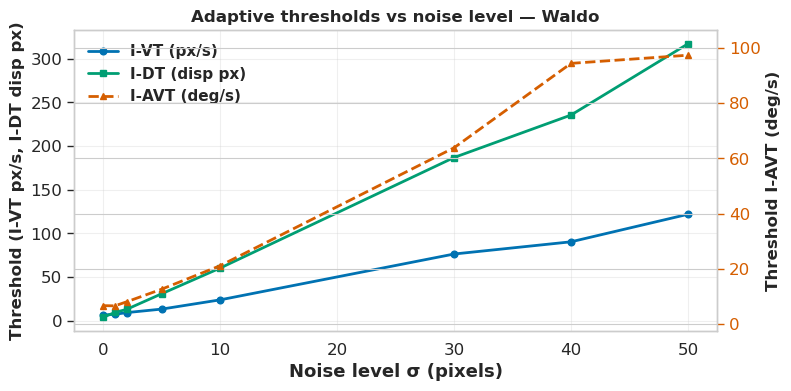

In [16]:
# ========================
# Adaptive Thresholds vs Noise — twin-axis plot
# ========================

c_ivt  = "#0072B2"   # blue
c_idt  = "#009E73"   # green
c_iavt = "#D55E00"   # orange

noise_levels    = sweep['noise_levels']
adaptive_ivt    = sweep['adaptive_ivt']
adaptive_iavt   = sweep['adaptive_iavt']
adaptive_idt    = sweep['adaptive_idt']

fig, ax1 = plt.subplots(figsize=(8, 4))

l1, = ax1.plot(noise_levels, adaptive_ivt, marker="o", linewidth=2,
               label="I-VT (px/s)", color=c_ivt)
l2, = ax1.plot(noise_levels, adaptive_idt, marker="s", linewidth=2,
               label="I-DT (disp px)", color=c_idt)
ax1.set_xlabel("Noise level σ (pixels)", fontsize=13, fontweight="bold")
ax1.set_ylabel("Threshold (I-VT px/s, I-DT disp px)", fontsize=12, fontweight="bold")
ax1.set_title("Adaptive thresholds vs noise level — Waldo", fontsize=12, fontweight="bold")
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis="both", which="both", labelsize=12)

ax2 = ax1.twinx()
iavt_finite = adaptive_iavt[np.isfinite(adaptive_iavt)]
if iavt_finite.size > 0:
    ymin, ymax = iavt_finite.min(), iavt_finite.max()
    if not np.isclose(ymin, ymax):
        pad = 0.1 * (ymax - ymin)
        ax2.set_ylim(ymin - pad, ymax + pad)
    l3, = ax2.plot(noise_levels, adaptive_iavt, marker="^", linewidth=2,
                   label="I-AVT (deg/s)", color=c_iavt, linestyle="--")
else:
    l3, = ax2.plot([], [], color=c_iavt, linestyle="--", marker="^", label="I-AVT (deg/s)")
ax2.set_ylabel("Threshold I-AVT (deg/s)", fontsize=12, fontweight="bold")
ax2.tick_params(axis="y", which="both", labelsize=12, colors=c_iavt)
for lbl in ax2.get_yticklabels(): lbl.set_color(c_iavt)

leg = ax1.legend([l1, l2, l3], [l.get_label() for l in [l1, l2, l3]],
                 loc="best", frameon=False, fontsize=11)
for txt in leg.get_texts(): txt.set_fontweight("bold")

plt.tight_layout()
plt.savefig("../outputs/adaptive_thresholds_vs_noise_Waldo.pdf",
            dpi=300, bbox_inches="tight")
plt.show()

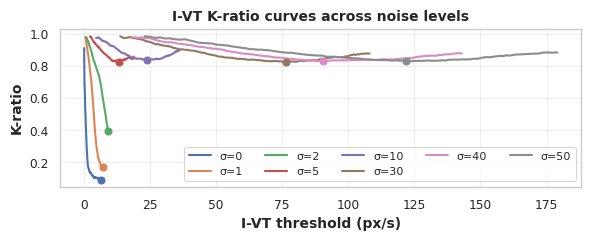

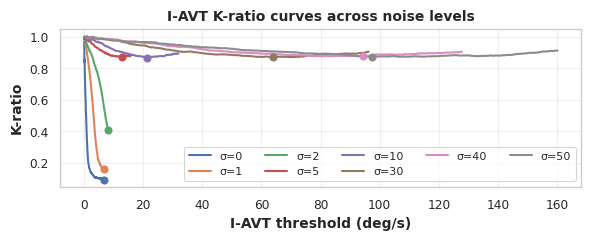

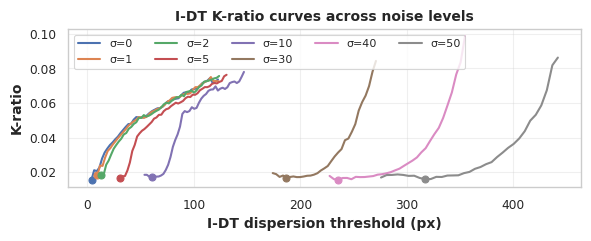

In [17]:
# ========================
# K-ratio Curves at Selected Noise Levels — I-VT, I-AVT, I-DT
# ========================

for algo, curves, xlabel in [
    ("I-VT",  sweep['ivt_curves'],  "I-VT threshold (px/s)"),
    ("I-AVT", sweep['iavt_curves'], "I-AVT threshold (deg/s)"),
    ("I-DT",  sweep['idt_curves'],  "I-DT dispersion threshold (px)"),
]:
    valid = {nl: (ths, krs) for nl, (ths, krs) in curves.items()
             if ths is not None}
    if not valid:
        continue
    plt.figure(figsize=(6, 2.5))
    for nl, (ths, krs) in valid.items():
        plt.plot(ths, krs, linewidth=1.5, label=f"σ={nl}")
        m = int(np.nanargmin(krs))
        plt.scatter(ths[m], krs[m], s=25, zorder=5)
    plt.xlabel(xlabel, fontsize=10, fontweight='bold')
    plt.ylabel("K-ratio", fontsize=10, fontweight='bold')
    plt.title(f"{algo} K-ratio curves across noise levels", fontsize=10, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.legend(ncol=min(len(valid), 5), fontsize=8)
    plt.tight_layout()
    plt.savefig(f"../outputs/{algo.lower().replace('-','')}_kratio_curves_noise_Waldo.pdf",
                dpi=300, bbox_inches="tight")
    plt.show()

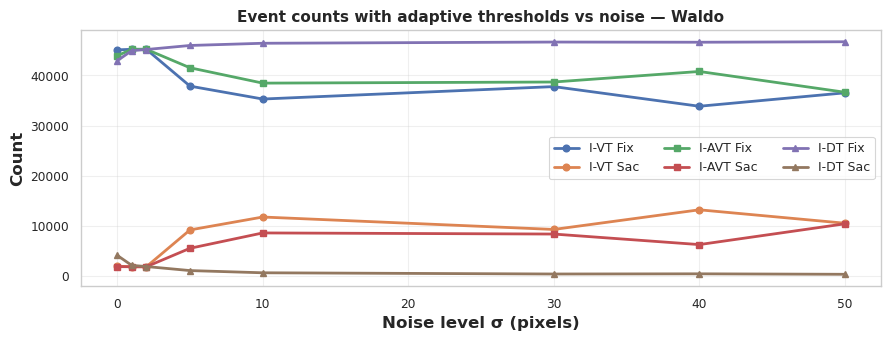


Noise		I-VT (px/s)	I-DT (disp px)	I-AVT (deg/s)
0.0		6.514		3.873		6.735
1.0		7.224		9.372		6.661
2.0		9.181		12.907		8.121
5.0		13.213		30.787		12.691
10.0		23.805		60.235		21.197
30.0		76.316		186.890		63.878
40.0		90.310		235.554		94.418
50.0		121.858		317.156		97.372


In [18]:
# ========================
# Event Counts vs Noise — All Algorithms
# ========================

plt.figure(figsize=(9, 3.5))
plt.plot(noise_levels, sweep['ivt_fix_counts'],  marker="o", linewidth=2, label="I-VT Fix")
plt.plot(noise_levels, sweep['ivt_sac_counts'],  marker="o", linewidth=2, label="I-VT Sac")
plt.plot(noise_levels, sweep['iavt_fix_counts'], marker="s", linewidth=2, label="I-AVT Fix")
plt.plot(noise_levels, sweep['iavt_sac_counts'], marker="s", linewidth=2, label="I-AVT Sac")
plt.plot(noise_levels, sweep['idt_fix_counts'],  marker="^", linewidth=2, label="I-DT Fix")
plt.plot(noise_levels, sweep['idt_sac_counts'],  marker="^", linewidth=2, label="I-DT Sac")
plt.xlabel("Noise level σ (pixels)", fontsize=12, fontweight='bold')
plt.ylabel("Count", fontsize=12, fontweight='bold')
plt.title("Event counts with adaptive thresholds vs noise — Waldo",
          fontsize=11, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(ncol=3, fontsize=9)
plt.tight_layout()
plt.savefig("../outputs/event_counts_vs_noise_Waldo.pdf",
            dpi=300, bbox_inches="tight")
plt.show()

# Summary table
print("\nNoise\t\tI-VT (px/s)\tI-DT (disp px)\tI-AVT (deg/s)")
for nl, ivt, idt, iavt in zip(
        noise_levels, sweep['adaptive_ivt'],
        sweep['adaptive_idt'],  sweep['adaptive_iavt']):
    iavt_str = f"{iavt:.3f}" if np.isfinite(iavt) else "NaN"
    print(f"{nl:.1f}\t\t{ivt:.3f}\t\t{idt:.3f}\t\t{iavt_str}")

## 11 · Noise Classification Accuracy vs EyeLink Reference (Fig. 4 bottom / Tables C4–C6)

For each noise level, classify with:
- **Fixed threshold** — optimized at σ=0, kept constant
- **Adaptive threshold** — re-optimized at each σ via K-ratio

Then compare against the EyeLink reference labels (`filtered_category_left`).
This reproduces the accuracy/F1 degradation curves from the paper.

In [19]:
# ========================
# Noise Classification: Fixed vs Adaptive Thresholds
# ========================
from sklearn.metrics import f1_score, accuracy_score

# --- Fixed (baseline) thresholds from σ=0 ---
fixed_ivt_threshold  = float(sweep['adaptive_ivt'][0])
fixed_idt_threshold  = float(sweep['adaptive_idt'][0])
fixed_iavt_threshold = float(sweep['adaptive_iavt'][0])

print(f"Fixed thresholds (σ=0):  I-VT={fixed_ivt_threshold:.3f} px/s  "
      f"I-AVT={fixed_iavt_threshold:.3f} deg/s  I-DT={fixed_idt_threshold:.3f} px")

def _f1_pair(y_true, y_pred):
    """Return (F1_fixation, F1_saccade) for labels 1=fixation, 2=saccade."""
    f1s = f1_score(y_true, y_pred, labels=[1, 2], average=None, zero_division=0)
    return float(f1s[0]), float(f1s[1])

results_table = []

for nl in NOISE_LEVELS:
    nx, ny = add_gaussian_noise(x_sample, y_sample, nl)
    dt_nl  = np.diff(time_sample)
    dt_nl  = np.where(dt_nl == 0, 1e-6, dt_nl)

    # ---- I-VT ----
    dx = np.diff(nx);  dy = np.diff(ny)
    vel_nl = np.sqrt(dx**2 + dy**2) / dt_nl
    x_ivt_nl = nx[:len(vel_nl)]; y_ivt_nl = ny[:len(vel_nl)]

    for thr_type, thr in [("fixed",    fixed_ivt_threshold),
                           ("adaptive", float(sweep['adaptive_ivt'][NOISE_LEVELS.index(nl)]))]:
        if not np.isfinite(thr):
            continue
        res = apply_ivt(vel_nl, x_ivt_nl, y_ivt_nl, thr)
        pred = np.array([1 if c == "fixation" else 2 for c in res['classifier']])
        L = min(len(filtered_category_left) - 1, len(pred))
        y_true = filtered_category_left[:L].astype(int)
        y_pred = pred[:L]
        f1_fix, f1_sac = _f1_pair(y_true, y_pred)
        results_table.append({
            'Algorithm': 'I-VT', 'Noise': nl, 'Threshold_type': thr_type,
            'Accuracy': accuracy_score(y_true, y_pred),
            'F1_Fix': f1_fix, 'F1_Sac': f1_sac,
        })

    # ---- I-AVT ----
    veff_nl, xc, yc, _ = compute_effective_velocity(nx, ny, time_sample)
    if len(veff_nl) > 10:
        for thr_type, thr in [("fixed",    fixed_iavt_threshold),
                               ("adaptive", float(sweep['adaptive_iavt'][NOISE_LEVELS.index(nl)]))]:
            if not np.isfinite(thr):
                continue
            res = apply_iavt(veff_nl, xc[:len(veff_nl)], yc[:len(veff_nl)], thr)
            pred = np.array([1 if c == "fixation" else 2 for c in res['classifier']])
            L = min(len(filtered_category_left) - 2, len(pred))
            y_true = filtered_category_left[:L].astype(int)
            y_pred = pred[:L]
            f1_fix, f1_sac = _f1_pair(y_true, y_pred)
            results_table.append({
                'Algorithm': 'I-AVT', 'Noise': nl, 'Threshold_type': thr_type,
                'Accuracy': accuracy_score(y_true, y_pred),
                'F1_Fix': f1_fix, 'F1_Sac': f1_sac,
            })

    # ---- I-DT ----
    for thr_type, thr in [("fixed",    fixed_idt_threshold),
                           ("adaptive", float(sweep['adaptive_idt'][NOISE_LEVELS.index(nl)]))]:
        if not np.isfinite(thr):
            continue
        res = apply_idt(nx, ny, time_sample, thr, thr, dur_threshold=0.050)
        pred = np.array([1 if c == "fixation" else 2 for c in res['classifier']])
        L = min(len(filtered_category_left), len(pred))
        y_true = filtered_category_left[:L].astype(int)
        y_pred = pred[:L]
        f1_fix, f1_sac = _f1_pair(y_true, y_pred)
        results_table.append({
            'Algorithm': 'I-DT', 'Noise': nl, 'Threshold_type': thr_type,
            'Accuracy': accuracy_score(y_true, y_pred),
            'F1_Fix': f1_fix, 'F1_Sac': f1_sac,
        })

noise_df = pd.DataFrame(results_table)
print(f"Done. {len(noise_df)} rows")
print(noise_df.head(12).round(3).to_string(index=False))

Fixed thresholds (σ=0):  I-VT=6.514 px/s  I-AVT=6.735 deg/s  I-DT=3.873 px
Done. 48 rows
Algorithm  Noise Threshold_type  Accuracy  F1_Fix  F1_Sac
     I-VT      0          fixed     0.919   0.956   0.588
     I-VT      0       adaptive     0.919   0.956   0.588
    I-AVT      0          fixed     0.848   0.918   0.090
    I-AVT      0       adaptive     0.848   0.918   0.090
     I-DT      0          fixed     0.869   0.927   0.412
     I-DT      0       adaptive     0.869   0.927   0.412
     I-VT      1          fixed     0.921   0.957   0.608
     I-VT      1       adaptive     0.917   0.955   0.572
    I-AVT      1          fixed     0.917   0.955   0.567
    I-AVT      1       adaptive     0.917   0.955   0.570
     I-DT      1          fixed     0.811   0.893   0.320
     I-DT      1       adaptive     0.889   0.940   0.389


### 11.1 · Accuracy Degradation Plot (Fig. 4 bottom row style)

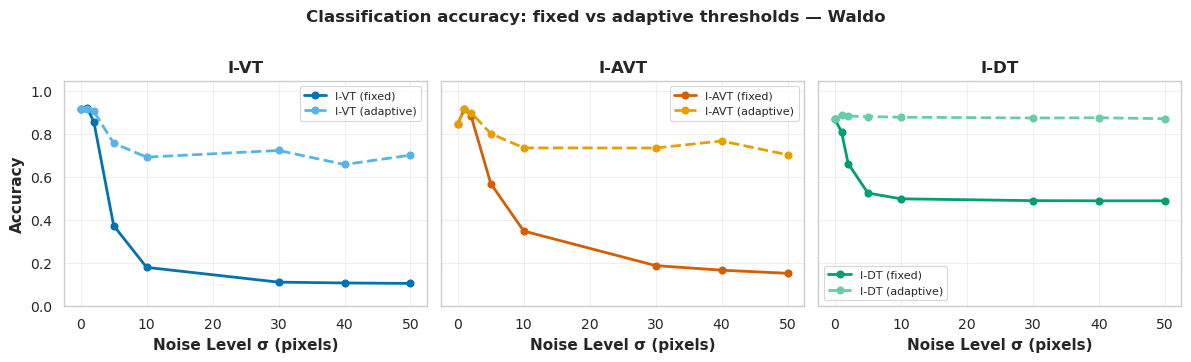

In [20]:
# ========================
# Accuracy vs Noise — Fixed vs Adaptive (Fig. 4 bottom)
# ========================

algos  = ['I-VT', 'I-AVT', 'I-DT']
colors = {'fixed': {'I-VT': '#0072B2', 'I-AVT': '#D55E00', 'I-DT': '#009E73'},
          'adaptive': {'I-VT': '#56B4E9', 'I-AVT': '#E69F00', 'I-DT': '#66CCAA'}}
styles = {'fixed': '-', 'adaptive': '--'}

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharey=True)

for ax, algo in zip(axes, algos):
    for thr_type in ['fixed', 'adaptive']:
        sub = noise_df[(noise_df['Algorithm'] == algo) &
                       (noise_df['Threshold_type'] == thr_type)]
        if sub.empty: continue
        label = f"{algo} ({thr_type})"
        ax.plot(sub['Noise'], sub['Accuracy'],
                marker='o', linewidth=2, linestyle=styles[thr_type],
                color=colors[thr_type][algo], label=label)
    ax.set_title(algo, fontsize=12, fontweight='bold')
    ax.set_xlabel("Noise Level σ (pixels)", fontsize=11, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='both', labelsize=10)
    ax.legend(fontsize=8, frameon=True)

axes[0].set_ylabel("Accuracy", fontsize=11, fontweight='bold')
plt.suptitle("Classification accuracy: fixed vs adaptive thresholds — Waldo",
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("../outputs/accuracy_vs_noise_Waldo.pdf", dpi=300, bbox_inches='tight')
plt.show()

### 11.2 · F1 Scores — Fixation and Saccade (Fig. C5 style)

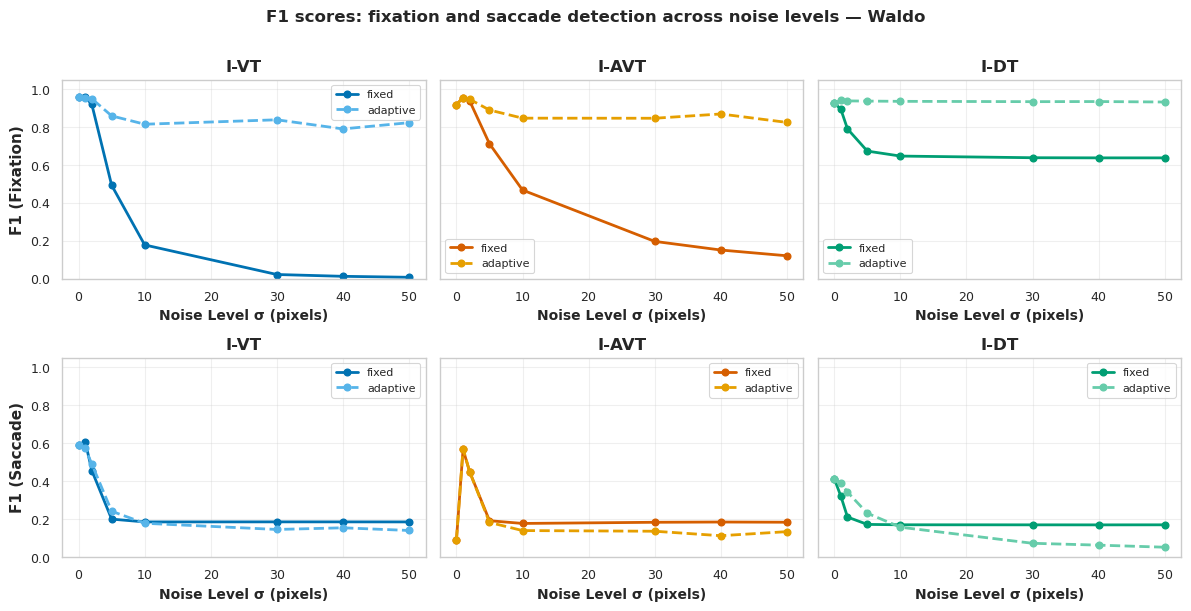

In [21]:
# ========================
# F1 Scores vs Noise — Fixation and Saccade (Fig. C5 of paper)
# ========================

fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharey='row')

for col, algo in enumerate(algos):
    for thr_type in ['fixed', 'adaptive']:
        sub = noise_df[(noise_df['Algorithm'] == algo) &
                       (noise_df['Threshold_type'] == thr_type)]
        if sub.empty: continue
        ls = '-' if thr_type == 'fixed' else '--'
        c  = colors[thr_type][algo]
        axes[0, col].plot(sub['Noise'], sub['F1_Fix'],
                          marker='o', linewidth=2, linestyle=ls,
                          color=c, label=thr_type)
        axes[1, col].plot(sub['Noise'], sub['F1_Sac'],
                          marker='o', linewidth=2, linestyle=ls,
                          color=c, label=thr_type)

    for row in range(2):
        axes[row, col].set_title(algo, fontsize=12, fontweight='bold')
        axes[row, col].set_xlabel("Noise Level σ (pixels)", fontsize=10, fontweight='bold')
        axes[row, col].set_ylim(0, 1.05)
        axes[row, col].grid(True, alpha=0.3)
        axes[row, col].tick_params(axis='both', labelsize=9)
        axes[row, col].legend(fontsize=8, frameon=True)

axes[0, 0].set_ylabel("F1 (Fixation)", fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel("F1 (Saccade)", fontsize=11, fontweight='bold')
plt.suptitle("F1 scores: fixation and saccade detection across noise levels — Waldo",
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("../outputs/f1_vs_noise_Waldo.pdf", dpi=300, bbox_inches='tight')
plt.show()

### 11.3 · Summary Table (Tables C4–C6 style)

In [22]:
# ========================
# Summary Table — Accuracy and F1 by Algorithm, Noise, Threshold Type
# ========================

for algo in algos:
    print(f"\n{'='*65}")
    print(f"  {algo}")
    print(f"{'='*65}")
    print(f"{'σ':>5}  {'Type':>8}  {'Acc':>6}  {'F1_Fix':>7}  {'F1_Sac':>7}")
    print(f"{'-'*65}")
    sub = noise_df[noise_df['Algorithm'] == algo].sort_values(['Noise', 'Threshold_type'])
    for _, row in sub.iterrows():
        print(f"{row['Noise']:>5.0f}  {row['Threshold_type']:>8s}  "
              f"{row['Accuracy']:>6.3f}  {row['F1_Fix']:>7.3f}  {row['F1_Sac']:>7.3f}")


  I-VT
    σ      Type     Acc   F1_Fix   F1_Sac
-----------------------------------------------------------------
    0  adaptive   0.919    0.956    0.588
    0     fixed   0.919    0.956    0.588
    1  adaptive   0.917    0.955    0.572
    1     fixed   0.921    0.957    0.608
    2  adaptive   0.906    0.949    0.489
    2     fixed   0.857    0.919    0.455
    5  adaptive   0.758    0.858    0.241
    5     fixed   0.374    0.493    0.199
   10  adaptive   0.693    0.815    0.177
   10     fixed   0.180    0.179    0.184
   30  adaptive   0.724    0.838    0.145
   30     fixed   0.111    0.023    0.185
   40  adaptive   0.659    0.790    0.153
   40     fixed   0.107    0.013    0.185
   50  adaptive   0.702    0.823    0.139
   50     fixed   0.105    0.008    0.184

  I-AVT
    σ      Type     Acc   F1_Fix   F1_Sac
-----------------------------------------------------------------
    0  adaptive   0.848    0.918    0.090
    0     fixed   0.848    0.918    0.090
    1  adap